# Credit-default experiment report

A compact, reproducible view of the data, model selection, and final evaluation. Production code owns all loading, splitting, training, and metric logic.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from credit_default_risk.config import (
    CATEGORICAL_FEATURES, DEFAULT_ARTIFACT_PATH, DEFAULT_DATA_PATH, NUMERIC_FEATURES
)
from credit_default_risk.data import load_dataset, split_dataset
from credit_default_risk.evaluate import evaluation_diagnostics, subgroup_metrics
from credit_default_risk.train import train_model

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold"})
dataset = load_dataset(DEFAULT_DATA_PATH)
split = split_dataset(dataset)
train = split.X_train.assign(default=split.y_train)

## Shape and data quality

The loader returns 30,000 rows and 24 columns: 23 features plus the target. There are no missing values. The 35 duplicate rows appear only after the unique ID is removed.

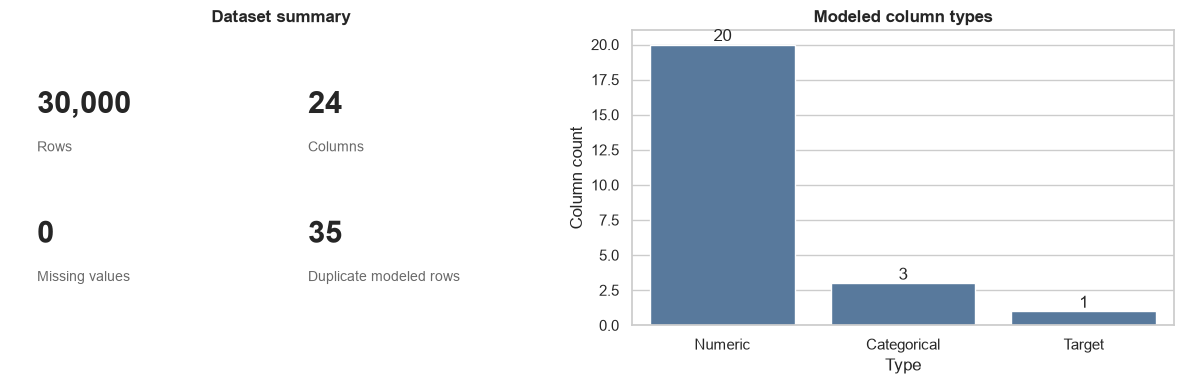

In [2]:
quality = {
    "Rows": len(dataset), "Columns": dataset.shape[1],
    "Missing values": int(dataset.isna().sum().sum()),
    "Duplicate modeled rows": int(dataset.duplicated().sum()),
}
feature_types = {"Numeric": len(NUMERIC_FEATURES), "Categorical": len(CATEGORICAL_FEATURES), "Target": 1}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axis("off")
for (label, value), (x, y) in zip(quality.items(), [(0.05, .72), (.55, .72), (.05, .28), (.55, .28)]):
    axes[0].text(x, y, f"{value:,}", fontsize=22, weight="bold")
    axes[0].text(x, y - .13, label, fontsize=10, color="dimgray")
axes[0].set_title("Dataset summary")
sns.barplot(x=list(feature_types), y=list(feature_types.values()), ax=axes[1], color="#4C78A8")
axes[1].bar_label(axes[1].containers[0])
axes[1].set(title="Modeled column types", xlabel="Type", ylabel="Column count")
plt.tight_layout(); plt.show()

## Training-partition exploration

The following exploration uses only the 18,000-row training partition. Validation and test data remain outside exploratory decisions.

### Target balance

Defaults make up 22.12% of training data. Accuracy alone would hide weak minority-class performance.

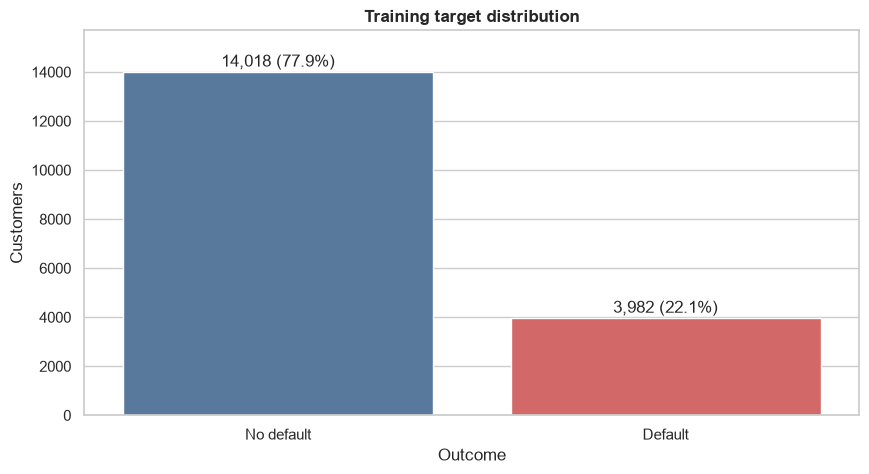

In [3]:
target_counts = train["default"].value_counts().sort_index()
ax = sns.barplot(x=["No default", "Default"], y=target_counts.values,
                 hue=["No default", "Default"], palette=["#4C78A8", "#E45756"], legend=False)
for patch, count in zip(ax.patches, target_counts.values):
    ax.text(patch.get_x() + patch.get_width() / 2, count + 200,
            f"{count:,} ({count / len(train):.1%})", ha="center")
ax.set(title="Training target distribution", xlabel="Outcome", ylabel="Customers",
       ylim=(0, target_counts.max() * 1.12))
plt.show()

### Credit limit and age

Credit limits are right-skewed; the training median is NT$140,000. Median age is 34. Both distributions overlap substantially across outcomes.

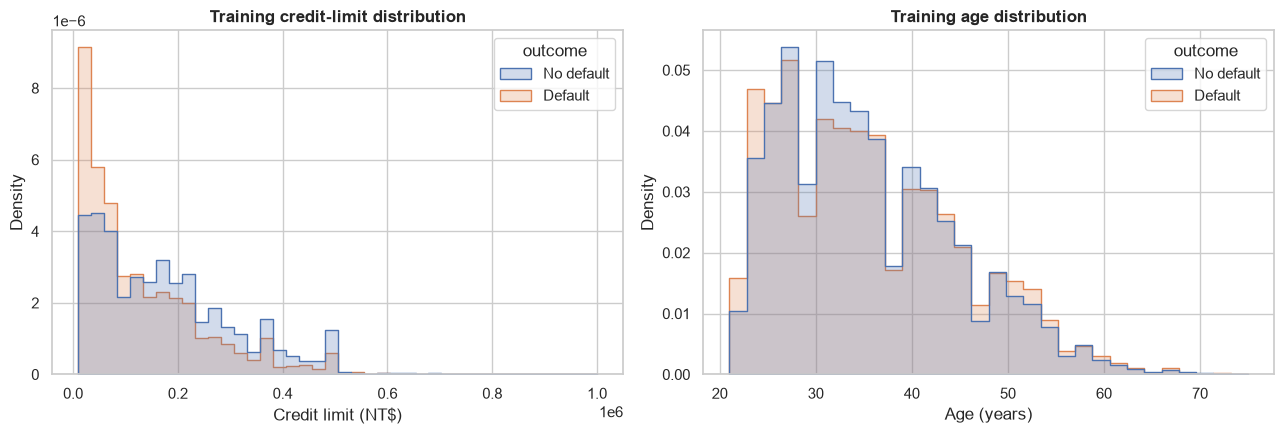

In [4]:
plot_frame = train.assign(outcome=train["default"].map({0: "No default", 1: "Default"}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=plot_frame, x="limit_bal", hue="outcome", bins=40, stat="density",
             common_norm=False, element="step", ax=axes[0])
axes[0].set(title="Training credit-limit distribution", xlabel="Credit limit (NT$)", ylabel="Density")
sns.histplot(data=plot_frame, x="age", hue="outcome", bins=30, stat="density",
             common_norm=False, element="step", ax=axes[1])
axes[1].set(title="Training age distribution", xlabel="Age (years)", ylabel="Density")
plt.tight_layout(); plt.show()

### Demographic fields

Observed differences are associations—not explanations or evidence of fair treatment. These sensitive or proxy-prone fields require subgroup validation and governance. Small `Other` groups are especially unstable.

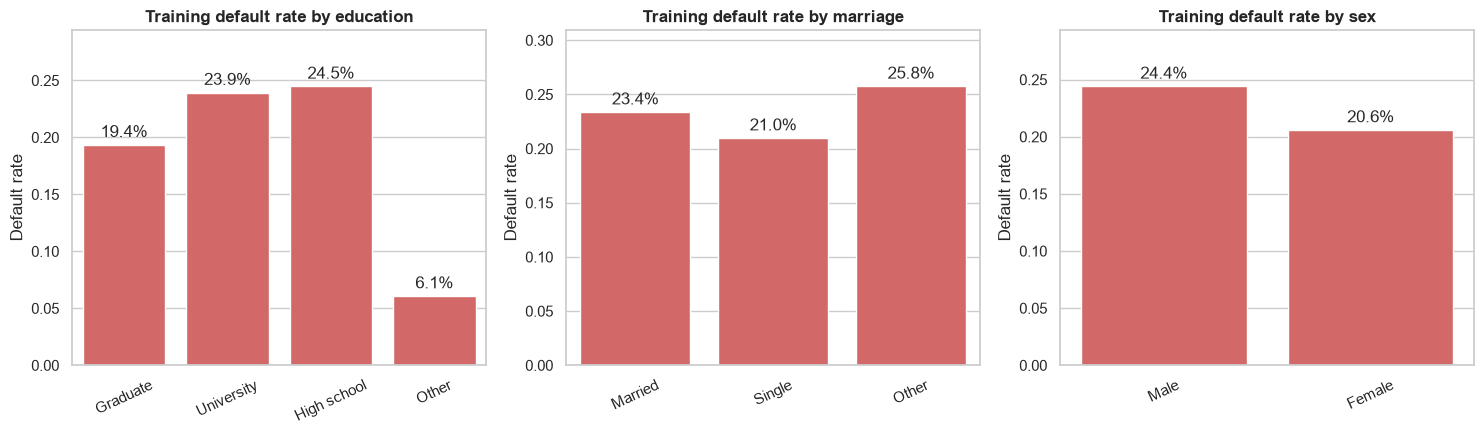

In [5]:
category_labels = {
    "education": {1: "Graduate", 2: "University", 3: "High school", 4: "Other"},
    "marriage": {1: "Married", 2: "Single", 3: "Other"},
    "sex": {1: "Male", 2: "Female"},
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feature in zip(axes, ["education", "marriage", "sex"]):
    rates = train.groupby(feature)["default"].mean().rename(index=category_labels[feature])
    sns.barplot(x=rates.index, y=rates.values, ax=ax, color="#E45756")
    ax.bar_label(ax.containers[0], labels=[f"{value:.1%}" for value in rates], padding=3)
    ax.set(title=f"Training default rate by {feature}", xlabel="", ylabel="Default rate",
           ylim=(0, max(rates.max() * 1.2, .28)))
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### Payment-status patterns

Recent repayment status has the clearest relationship with default. In September, the training default rate rises from 12.8% at status `0` to 69.7% for a two-month delay. Rare extreme statuses are unstable.

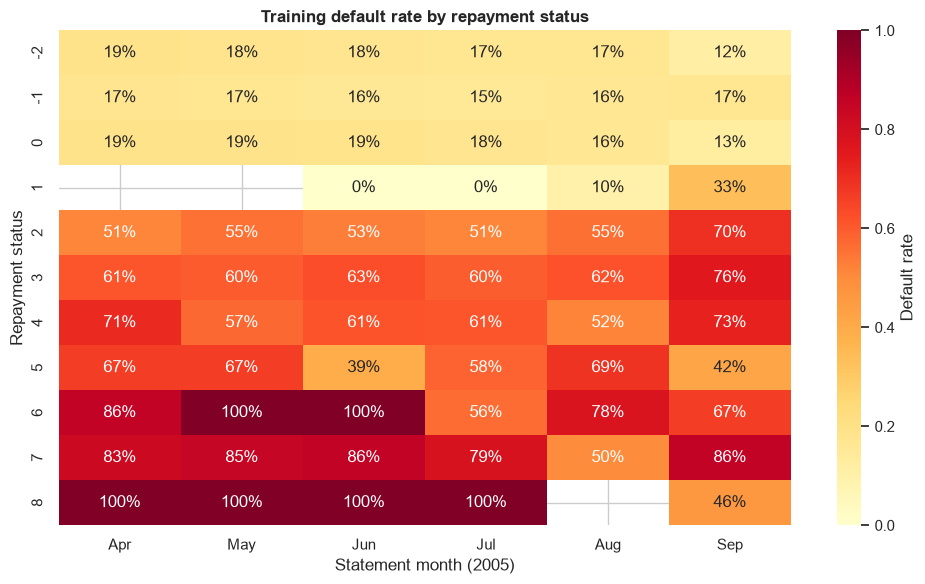

In [6]:
status_columns = ["pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"]
status_months = {"pay_0": "Sep", "pay_2": "Aug", "pay_3": "Jul",
                 "pay_4": "Jun", "pay_5": "May", "pay_6": "Apr"}
status_long = train.melt(id_vars="default", value_vars=status_columns,
                         var_name="month", value_name="payment_status")
status_rates = status_long.pivot_table(index="payment_status", columns="month",
                                       values="default", aggfunc="mean")
status_rates = status_rates.rename(columns=status_months)[["Apr", "May", "Jun", "Jul", "Aug", "Sep"]]
plt.figure(figsize=(10, 6))
sns.heatmap(status_rates, cmap="YlOrRd", vmin=0, vmax=1, annot=True, fmt=".0%",
            cbar_kws={"label": "Default rate"})
plt.title("Training default rate by repayment status")
plt.xlabel("Statement month (2005)"); plt.ylabel("Repayment status")
plt.tight_layout(); plt.show()

### Monthly bills and payments

Average bills are similar across outcomes. Average payments are consistently lower among customers who defaulted.

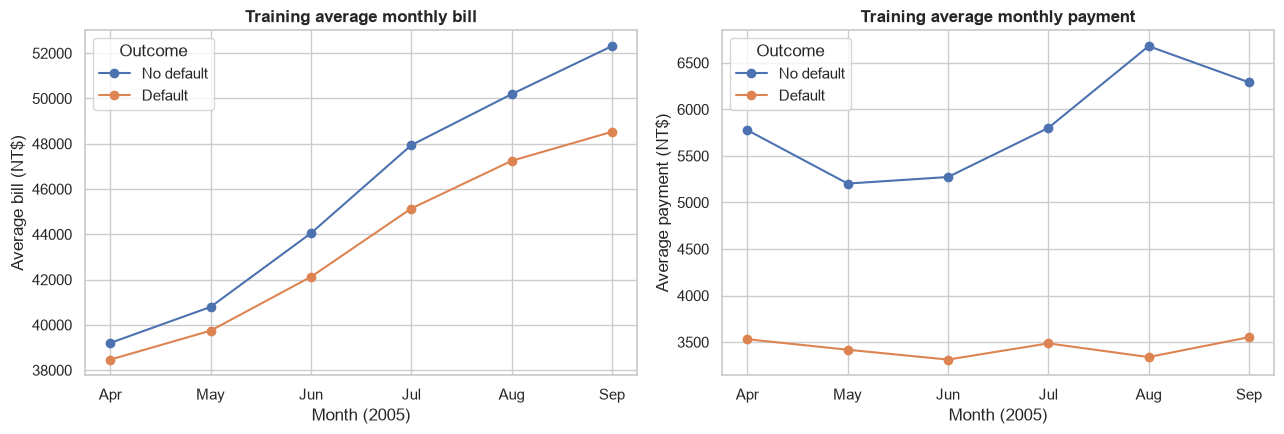

In [7]:
months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
bill_columns = [f"bill_amt{i}" for i in range(6, 0, -1)]
payment_columns = [f"pay_amt{i}" for i in range(6, 0, -1)]
outcome_labels = {0: "No default", 1: "Default"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for outcome, group in train.groupby("default"):
    axes[0].plot(months, group[bill_columns].mean(), marker="o", label=outcome_labels[outcome])
    axes[1].plot(months, group[payment_columns].mean(), marker="o", label=outcome_labels[outcome])
axes[0].set(title="Training average monthly bill", xlabel="Month (2005)", ylabel="Average bill (NT$)")
axes[1].set(title="Training average monthly payment", xlabel="Month (2005)", ylabel="Average payment (NT$)")
for ax in axes: ax.legend(title="Outcome")
plt.tight_layout(); plt.show()

### Strongest feature relationships

Repayment-status fields dominate the strongest linear relationships. Correlation is only a screening view; it misses nonlinear effects and does not imply causation.

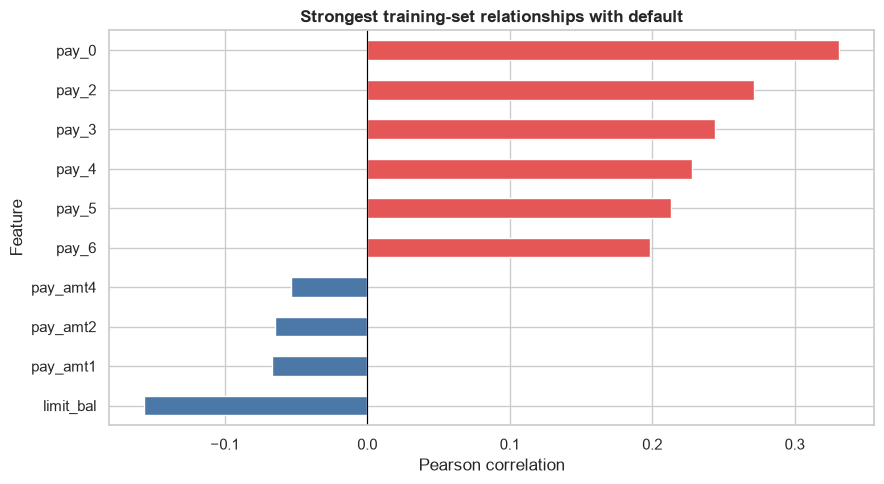

In [8]:
target_correlations = (train.corr(numeric_only=True)["default"].drop("default")
                       .sort_values(key=lambda values: values.abs(), ascending=False)
                       .head(10).sort_values())
colors = ["#4C78A8" if value < 0 else "#E45756" for value in target_correlations]
ax = target_correlations.plot.barh(color=colors, figsize=(9, 5))
ax.axvline(0, color="black", linewidth=.8)
ax.set(title="Strongest training-set relationships with default",
       xlabel="Pearson correlation", ylabel="Feature")
plt.tight_layout(); plt.show()

## Production experiment

The notebook now calls the same production function as the training command. That function fits and calibrates both candidates, selects by validation ROC-AUC with Brier score as tie-breaker, then chooses the highest-precision threshold meeting 60% validation recall.

In [9]:
bundle = train_model(DEFAULT_DATA_PATH, DEFAULT_ARTIFACT_PATH)
test_probability = bundle["model"].predict_proba(split.X_test)[:, 1]
diagnostics = evaluation_diagnostics(split.y_test, test_probability, bundle["threshold"])
group_results = subgroup_metrics(
    split.X_test, split.y_test, test_probability, bundle["threshold"], CATEGORICAL_FEATURES
)

### Model selection

Calibrated histogram gradient boosting wins on validation ROC-AUC and Brier score. Recall at `0.5` is shown for comparison; operational recall uses the separately selected threshold.

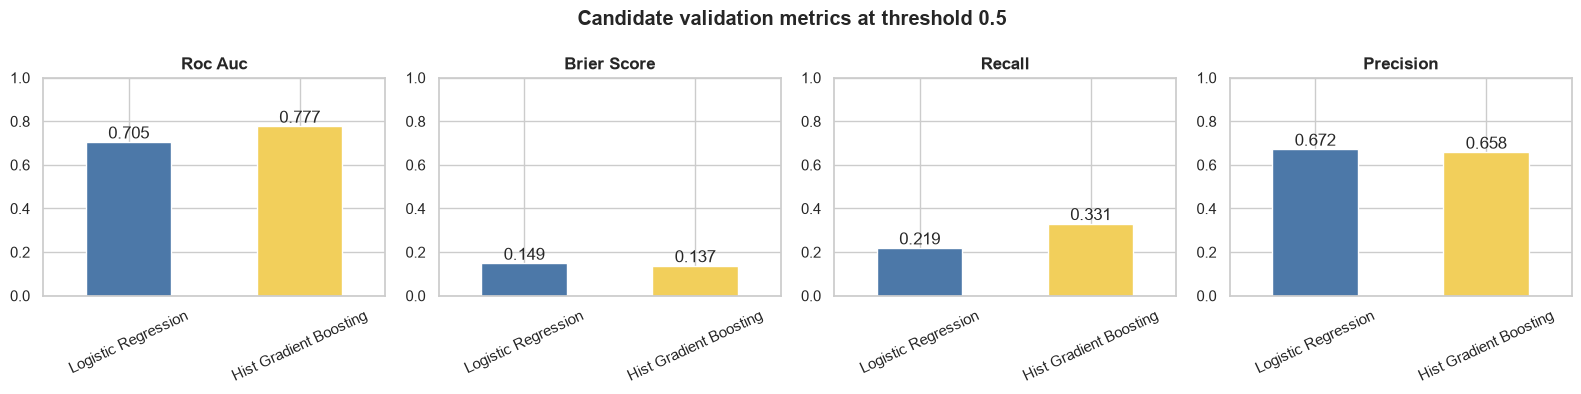

In [10]:
candidate_metrics = pd.DataFrame(bundle["candidate_validation_metrics"]).T
candidate_metrics.index = candidate_metrics.index.str.replace("_", " ").str.title()
metrics_to_plot = ["roc_auc", "brier_score", "recall", "precision"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics_to_plot):
    candidate_metrics[metric].plot.bar(ax=ax, color=["#4C78A8", "#F2CF5B"])
    ax.set(title=metric.replace("_", " ").title(), xlabel="", ylim=(0, 1))
    ax.tick_params(axis="x", rotation=25)
    ax.bar_label(ax.containers[0], fmt="%.3f")
plt.suptitle("Candidate validation metrics at threshold 0.5", weight="bold")
plt.tight_layout(); plt.show()

## Final test evaluation

At the fixed threshold `0.2260`, test ROC-AUC is 0.7863, recall is 0.6368, precision is 0.4801, and Brier score is 0.1327. These are exercise results, not production standards.

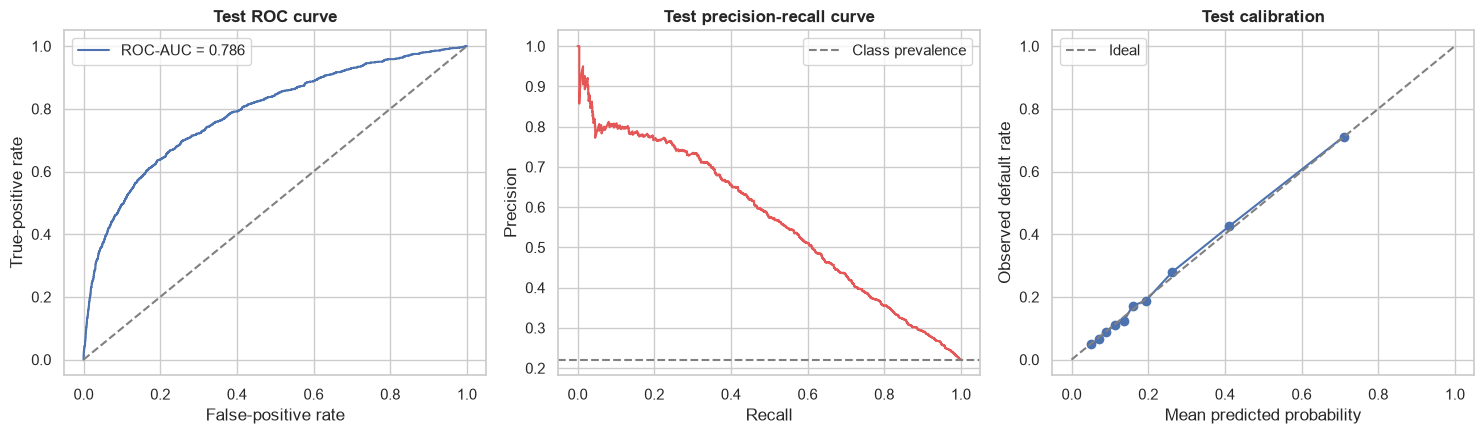

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(diagnostics["false_positive_rate"], diagnostics["true_positive_rate"],
             label=f"ROC-AUC = {bundle['test_metrics']['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Test ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[0].legend()
axes[1].plot(diagnostics["recall"], diagnostics["precision"], color="#E45756")
axes[1].axhline(split.y_test.mean(), linestyle="--", color="gray", label="Class prevalence")
axes[1].set(title="Test precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()
axes[2].plot(diagnostics["predicted_rate"], diagnostics["observed_rate"], marker="o")
axes[2].plot([0, 1], [0, 1], "--", color="gray", label="Ideal")
axes[2].set(title="Test calibration", xlabel="Mean predicted probability", ylabel="Observed default rate")
axes[2].legend()
plt.tight_layout(); plt.show()

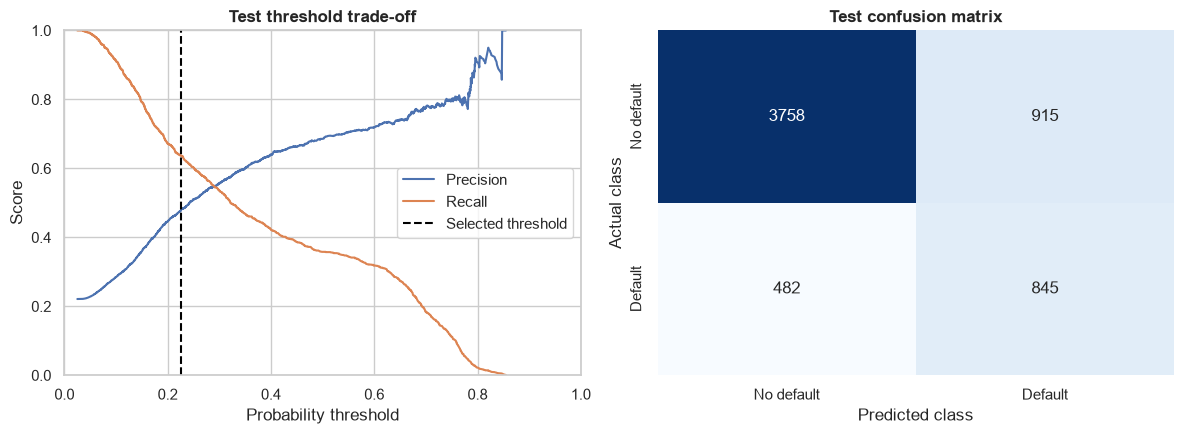

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(diagnostics["thresholds"], diagnostics["precision"][:-1], label="Precision")
axes[0].plot(diagnostics["thresholds"], diagnostics["recall"][:-1], label="Recall")
axes[0].axvline(bundle["threshold"], color="black", linestyle="--", label="Selected threshold")
axes[0].set(title="Test threshold trade-off", xlabel="Probability threshold", ylabel="Score", xlim=(0, 1), ylim=(0, 1))
axes[0].legend()
sns.heatmap(diagnostics["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set(title="Test confusion matrix", xlabel="Predicted class", ylabel="Actual class",
            xticklabels=["No default", "Default"], yticklabels=["No default", "Default"])
plt.tight_layout(); plt.show()

### Subgroup diagnostics

Test recall and precision vary across demographic groups. This is an initial aggregate audit, not a fairness determination; sample sizes, uncertainty, harms, and policy context still matter.

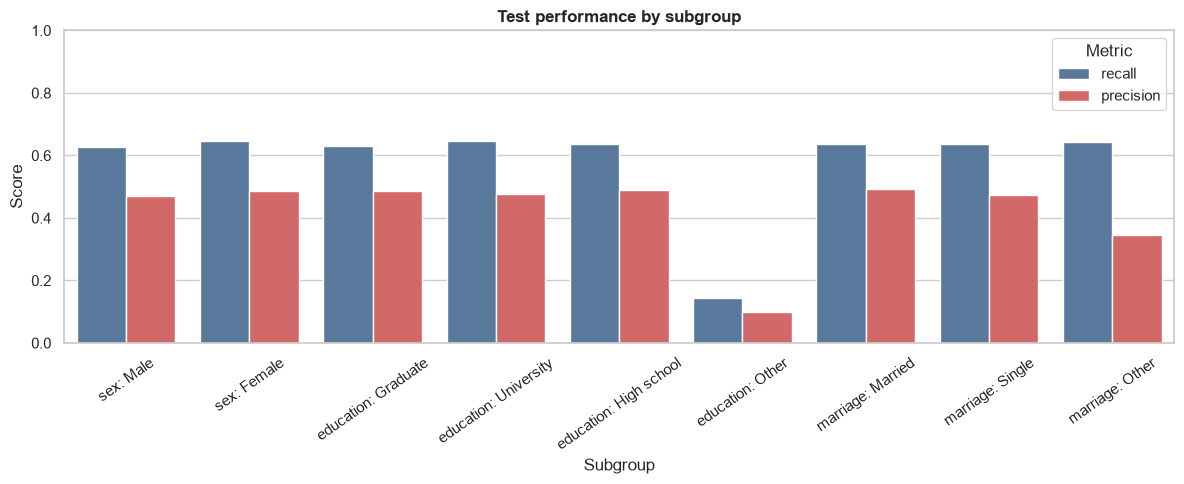

,group,count,observed_default_rate,predicted_high_risk_rate,recall,precision
0,sex: Male,2372,0.241,0.321,0.626,0.470
1,sex: Female,3628,0.208,0.275,0.645,0.487
2,education: Graduate,2141,0.192,0.249,0.631,0.488
3,education: University,2775,0.233,0.316,0.646,0.476
4,education: High school,989,0.265,0.345,0.637,0.490
5,education: Other,95,0.074,0.105,0.143,0.100
6,marriage: Married,2731,0.239,0.308,0.637,0.493
7,marriage: Single,3196,0.207,0.279,0.637,0.472
8,marriage: Other,73,0.192,0.356,0.643,0.346


In [13]:
group_results["group"] = group_results.apply(
    lambda row: f"{row['feature']}: {category_labels[row['feature']][row['value']]}", axis=1
)
group_plot = group_results.melt(id_vars=["group", "count"], value_vars=["recall", "precision"],
                                var_name="metric", value_name="score")
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=group_plot, x="group", y="score", hue="metric", palette=["#4C78A8", "#E45756"])
ax.set(title="Test performance by subgroup", xlabel="Subgroup", ylabel="Score", ylim=(0, 1))
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Metric")
plt.tight_layout(); plt.show()
group_results[["group", "count", "observed_default_rate", "predicted_high_risk_rate", "recall", "precision"]].round(3)

## Findings, limitations, and implications

- Repayment history is the clearest signal; no single feature separates outcomes cleanly.
- Histogram gradient boosting improves ranking and calibration over the logistic baseline.
- The lower operational threshold reaches the recall target but produces more false positives.
- Demographic performance differences require deeper fairness review before any real use.
- This single 2005 Taiwan cohort cannot establish current performance or temporal stability.
- Default prediction does not show that outreach will change an outcome. Risk bands remain heuristic.